In [281]:
import pandas as pd
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

mpl.style.use('default')
mpl.rcParams['axes.linewidth'] = 7  # set the value globally
mpl.rcParams['xtick.major.size'] = 24
mpl.rcParams['xtick.major.width'] = 7
mpl.rcParams['xtick.minor.size'] = 16
mpl.rcParams['xtick.minor.width'] = 7
mpl.rcParams['ytick.major.size'] = 24
mpl.rcParams['ytick.major.width'] = 7
mpl.rcParams['ytick.labelsize'] = 75
mpl.rcParams['xtick.labelsize'] = 75
mpl.rcParams['ytick.minor.size'] = 16
mpl.rcParams['ytick.minor.width'] = 7
mpl.rcParams['font.size'] = 55
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['svg.fonttype'] = 'none'

In [282]:
direct = r'D:\Patrick\Infection\48_infection_tiles'

well_name = {
    0: 'time',
    1: 'loc',
    2: 'construct',
    3: 'well',
    4: 'replicate',
    }


check_dic = {
            1: 'Donor',
            2: 'Acceptor',
            3: 'DirectAcceptor'}

file_list = glob.glob(direct+'/*.csv')
df = pd.DataFrame()
for i in file_list:
    csv_file = pd.read_csv(i).iloc[:, 1:]
    base = os.path.basename(i).split('.')[0]
    tmp_df = pd.DataFrame()
    for iterable in range(int(len(csv_file.columns)/4)):
        tmp_csv = csv_file.iloc[:, iterable*4:  iterable*4+4]
        set_dic = pd.DataFrame()
        for x in range(4):
            name = tmp_csv.iloc[:, ]
            tmp_dic = {}
            p = tmp_csv.iloc[:, x].tolist()
            if x == 0:
                tmp_dic['Area'] = [p[0]]
                set_area = tmp_dic
            elif x==1: 
                set_area['donor_mean'] = [p[0]]
                set_area['acceptor_mean'] = [p[1]]
                set_area['directA_mean'] = [p[2]]
                set_area['mCherry_mean'] = [p[3]]
            elif x==2: 
                set_area['donor_min'] = [p[0]]
                set_area['acceptor_min'] = [p[1]]
                set_area['directA_min'] = [p[2]]
                set_area['mCherry_min'] = [p[3]]
            else:
                set_area['donor_max'] = [p[0]]
                set_area['acceptor_max'] = [p[1]]
                set_area['directA_max'] = [p[2]]
                set_area['mCherry_max'] = [p[3]]
                set_dic = pd.concat([set_dic, pd.DataFrame(set_area)]) 
        set_dic['label'] = iterable
        tmp_df = pd.concat([tmp_df, set_dic])
    
    for v, x in enumerate(base.split('_')):
        column_name = well_name[v]
        tmp_df[column_name] = x
    df = pd.concat([df, tmp_df])    
df = df.reset_index(drop=True) 

In [283]:
df['corrected_da'] = df['directA_mean'] - df['mCherry_mean'] * 0.173

df['corrected_acceptor'] = df['acceptor_mean'] - (df['donor_mean'] * 0.47) - (df['corrected_da'] * 0.068)
df['Efret'] = df['corrected_acceptor'] / (df['corrected_acceptor'] + df['donor_mean'])

df =df[df['directA_max'] < 64000]

In [284]:
def split_df_in_half(df):
    total_length = len(df)
    half_point = int(total_length/2)
    first_half, second_half = df.iloc[0:half_point], df.iloc[half_point:]
    return first_half, second_half

def reset_label_to_zero(df):
    df_label_reset = df['label'].min()
    df['label'] = df['label'] - df_label_reset
    return df

def nuclei_divided_cyto_ratio(nuclei, cyto):
    return nuclei/cyto

def merge_dfs(left_df, right_df):
    return pd.merge(left_df, right_df, on='label', suffixes=('_nuclei', '_cyto'))
    
def derive_ratios(df) :   
    nuclei_Efret, nuclei_da, cyto_Efret, cyto_da = df['Efret_nuclei'], df['directA_mean_nuclei'], df['Efret_cyto'], df['directA_mean_cyto']
    Efret_ratio, directA_ratio = nuclei_divided_cyto_ratio(nuclei_Efret, cyto_Efret), nuclei_divided_cyto_ratio(nuclei_da, cyto_da)
    return Efret_ratio, directA_ratio

def create_ratios(df):
    nuclei_df, cyto_df = split_df_in_half(df)
    cyto_df = reset_label_to_zero(cyto_df)
    merge_df = merge_dfs(nuclei_df, cyto_df)
    Efret_ratio, directA_ratio = derive_ratios(merge_df)
    
    if len(Efret_ratio) != len(directA_ratio):
        raise ValueError(f'length Efret of {len(Efret_ratio)} is not equal to length directA {len(directA_ratio)}') 
    merge_df['Efret_ratio'] = Efret_ratio
    merge_df['DirectA_ratio'] = directA_ratio 
    return merge_df

def remerge_and_create_ratios(df, groupby=['construct', 'replicate']):
    return df.groupby(groupby, as_index=False).apply(lambda x: create_ratios(x)).reset_index(drop=True)    

def set_box_color(bp, color):
    plt.setp(bp['boxes'], color=color)
    plt.setp(bp['whiskers'], color=color)
    plt.setp(bp['caps'], color=color)

In [333]:
cyto_nuc_df = remerge_and_create_ratios(df)
cyto_nuc_df = cyto_nuc_df[
    (cyto_nuc_df['mCherry_mean_cyto'] > 1500) |
    (cyto_nuc_df['mCherry_mean_cyto'] < 500)
]

cyto_nuc_df['infection'] = np.where(
    cyto_nuc_df['mCherry_mean_cyto'] > 1500,
    'infected',
    'noninfected'
)
cyto_nuc_df = cyto_nuc_df.loc[cyto_nuc_df['mCherry_max_cyto'] < 64000]
cyto_nuc_df = cyto_nuc_df.loc[cyto_nuc_df['DirectA_ratio'] <4]

C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\3583066122.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(groupby, as_index=False).apply(lambda x: create_ratios(x)).reset_index(drop=True)


In [359]:
from calculations.significance import set_pvalue
from pandas.api.types import CategoricalDtype
multicolor=False
plotting_df = cyto_nuc_df 

constructs= ['1','2', '3', '4', '5', '6', '7','8', '9', '10', '11', '12']

plotting_df['construct'] = plotting_df['construct_cyto'].str.split('-').str[1]

cat_type = CategoricalDtype(categories=constructs, ordered=True)
plotting_df['construct'] = plotting_df['construct'].astype(cat_type)

plotting_df = plotting_df.sort_values(['construct'])

fig, ax = plt.subplots(2, 12, sharey='row', figsize=(50, 20))
ax = ax.flatten()

colors = ['dodgerblue', 'purple']

generator = plotting_df.groupby(['construct'])
for index, tile in enumerate(generator):
    tmp_df = tile[1]

    infected_df, noninfected_df = tmp_df.loc[(tmp_df['infection'] == 'infected')], tmp_df.loc[(tmp_df['infection'] == 'noninfected')]
    
    df_list = [noninfected_df, infected_df]
    
    da_sign_list = []
    ef_sign_list = []
    
    for i in range(2):
        it_df = df_list[i]
        color = colors[i]
        
        ef_data = it_df['Efret_ratio']
        da_data = it_df['DirectA_ratio']

        da_sign_list.append(da_data)
        ef_sign_list.append(ef_data)

        bp_list_1 = []
        bp_list_2 = []
        
            
        bp1 = ax[index].boxplot(da_data, positions= [i], widths=0.8, showfliers=False)
        bp2 = ax[index+len(constructs)].boxplot(ef_data, positions= [i], widths=0.8, showfliers=False)

        x_list = []
        if multicolor:
            mcolor = ['k', 'r', 'g', 'b', 'purple', 'yellow']
            for rep in it_df['replicate_cyto'].unique():
                c = mcolor[int(rep)]
                
                rep_data = it_df.loc[it_df['replicate_cyto'] == rep]
                directacceptor_ratio = rep_data['DirectA_ratio']
                efret_ratio = rep_data['Efret_ratio']

                data_list = [directacceptor_ratio, efret_ratio]
                x_list = []
                for dataset in data_list:
                    x_list.append(i + np.random.uniform(-0.1, 0.1, size=len(dataset)))
                ax[index].scatter(x_list[0], directacceptor_ratio, color = c,edgecolor='k', s=500, alpha=0.5)
                ax[index+len(constructs)].scatter(x_list[1], efret_ratio, color = c, edgecolor='k', s=500, alpha=0.5)

        else:
            color=colors[i]
            data_list = [da_data, ef_data]
            for dataset in data_list:
                x_list.append(i + np.random.uniform(-0.1, 0.1, size=len(dataset)))
        
            ax[index].scatter(x_list[0], da_data, color=color, edgecolor='k', s=500, alpha=0.5)
            ax[index+len(constructs)].scatter(x_list[1], ef_data, color=color, edgecolor='k', s=500, alpha=0.5)
        
        list_bp = [bp1, bp2]
        for box in list_bp:
            set_box_color(box, color='k')
            for element in ['boxes', 'whiskers', 'caps', 'medians']:
                for line in box[element]:
                    line.set_linewidth(8)

    ha= 'center'
    data_variables = [da_sign_list, ef_sign_list]
    for set_index, data_values in enumerate(data_variables):
        _, pvalue = stats.ttest_ind(data_values[0], data_values[1])
        star_value = set_pvalue(pvalue) 
        match set_index:
            case 0:
                ax[index].text(0.5, 2.3, s=star_value, ha=ha, fontsize=50)
            case 1:
                ax[index+len(constructs)].text(0.5, 1.2, s=star_value, ha=ha, fontsize=50)
        
    ax[index].set_title(constructs[index], fontsize=75)
    ax[index].axhline(1.0, linestyle='--', color='teal', linewidth=3)
xticks = ['Non', 'inf']
'''for axes in ax[0:6]:
    axes.set_xticklabels([])'''
for axes in ax[0:]:
    axes.set_xticklabels(xticks, fontsize=60, rotation= -45)

plt.subplots_adjust(hspace=0.05, wspace=0.2)

plt.savefig(r'W:\OneDrive\Virus\Paper1\Paper1_figures\cyto_nuclei_boxplot_infection_NonVsInf_dualcolor.svg', format='svg', bbox_inches='tight')

C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\446194118.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  generator = plotting_df.groupby(['construct'])


In [287]:
plotting_df

,Area_nuclei,donor_mean_nuclei,acceptor_mean_nuclei,directA_mean_nuclei,mCherry_mean_nuclei,donor_min_nuclei,acceptor_min_nuclei,directA_min_nuclei,mCherry_min_nuclei,donor_max_nuclei,...,construct_cyto,well_cyto,replicate_cyto,corrected_da_cyto,corrected_acceptor_cyto,Efret_cyto,Efret_ratio,DirectA_ratio,infection,construct
0,266.386,1429.745,2670.247,3958.275,195.066,1064.0,2047.000,3012.000,129.000,1845.0,...,tile-1,A6,1,4116.387897,1862.444283,0.558879,0.980021,0.953677,noninfected,1
58,175.971,981.554,1810.773,2431.445,159.397,678.0,1305.000,1602.000,121.000,1297.0,...,tile-1,A5,2,1984.459142,1047.682788,0.553159,0.989148,1.208456,noninfected,1
57,284.765,878.008,1638.205,2078.739,166.214,640.0,1313.000,1595.000,112.000,1165.0,...,tile-1,A5,2,2014.182706,1073.413246,0.555352,0.995735,1.016280,noninfected,1
56,205.441,974.001,1791.177,2422.532,162.410,668.0,1345.000,1603.000,111.000,1239.0,...,tile-1,A5,2,2656.158940,1273.916402,0.552322,0.988247,0.902101,noninfected,1
55,278.005,1498.660,2934.253,4647.345,698.850,1095.0,2214.000,3625.000,511.000,2010.0,...,tile-1,A5,2,4379.467019,1871.582143,0.562795,0.998393,1.038421,noninfected,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,227.305,9881.927,12372.860,22854.521,516.620,4966.0,5119.307,8579.278,359.458,12325.0,...,tile-12,D10,2,13511.064120,3799.096110,0.394208,0.976067,1.682095,noninfected,12
213,214.524,10006.841,12561.261,22928.371,404.345,6336.0,6652.178,11832.669,300.649,12827.0,...,tile-12,D10,2,12124.515096,3477.800803,0.396168,0.975545,1.880657,noninfected,12
214,292.793,9483.159,12160.169,22707.842,1779.933,4534.0,3752.932,6656.787,805.860,12052.0,...,tile-12,D10,2,13092.545325,3713.239208,0.399826,0.986809,1.706695,noninfected,12
205,287.511,7744.536,9936.491,17118.070,2127.536,4499.0,5767.577,10057.903,1280.722,10423.0,...,tile-12,D10,2,10844.357130,3440.939145,0.400721,0.997566,1.540524,infected,12


In [314]:
dd_df = pd.read_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\figure_3_delta_Efret.pkl')

In [315]:
dd_df

,construct,experiment,experimentparameter,cell_count,delta_Efret_median_well,delta_Efret_list_well,experiment_delta_median,well_count,cell_population,pvalue,star_value,base_position,subposition_offset,plot_position
0,1,Infection,Growth,"[128, 218, 257, 527, 617]","[-0.004042616923530862, -0.003599492690285977,...","[[-0.03331562863690585, -0.03202280209616948, ...",-0.003683,5,1747,1.000000,ns,1,-0.217391,0.782609
1,1,Infection,infected,"[21, 34, 28, 78]","[0.003339863821990474, 0.00784855405279511, 0....","[[-0.0049675248543270545, -0.00234268759237565...",0.006052,4,161,0.001202,**,1,0.217391,1.217391
0,2,Infection,Growth,"[82, 112, 164, 334, 313, 223, 236]","[0.00319370292039009, 0.0004623024753688809, 0...","[[-0.009151986044238114, -0.015486803602842214...",0.000742,7,1464,1.000000,ns,2,-0.217391,1.782609
1,2,Infection,infected,"[44, 55, 39]","[0.006415034604611514, 0.00380049572172797, 0....","[[-0.004728379284820228, -0.006368171184731153...",0.003800,3,138,0.078419,ns,2,0.217391,2.217391
0,3,Infection,Growth,"[207, 248, 256, 297, 343]","[7.932271759902854e-05, 0.001054185239694555, ...","[[-0.03152028194924972, -0.012768452677973996,...",-0.001204,5,1351,1.000000,ns,3,-0.217391,2.782609
1,3,Infection,infected,"[53, 63, 45, 29]","[0.005482066037537758, 0.0081331688300178, 0.0...","[[-0.013708537696057788, -0.011556460821473435...",0.007461,4,190,0.000242,***,3,0.217391,3.217391
0,4,Infection,Growth,"[75, 76, 302, 306, 476, 523]","[0.001920981217132245, 0.0008466177460697555, ...","[[-0.023053775645071217, -0.016855677880885322...",0.001425,6,1758,1.000000,ns,4,-0.217391,3.782609
1,4,Infection,infected,"[31, 82, 61, 55, 82, 91]","[0.003579628299219928, -0.011226924201234195, ...","[[0.03697593515268588, 0.003496679650174639, 0...",-0.006358,6,402,0.031744,*,4,0.217391,4.217391
0,5,Infection,Growth,"[116, 147, 272, 457, 287, 220, 261, 595]","[-0.001300126586098127, 0.0005229759778828114,...","[[-0.005604419278215256, -0.007789623789408451...",-0.002439,8,2355,1.000000,ns,5,-0.217391,4.782609
1,5,Infection,infected,"[34, 20, 48, 32, 49, 20, 44]","[0.01085068087883323, 0.008773201470792885, 0....","[[0.00902073444535395, 0.016250025805895907, 0...",0.006166,7,247,0.000230,***,5,0.217391,5.217391


In [316]:
std = dd_df.loc[dd_df['experimentparameter'] == 'infected'].groupby('construct', as_index=False)['delta_Efret_median_well'].apply(lambda x: x[1].std())
std = std.rename(columns={'delta_Efret_median_well': 'dEfret_std'})
small_df = dd_df.groupby(['construct'], as_index=False)['experiment_delta_median'].apply(lambda x: x[1] - x[0])
small_df =small_df.rename(columns={'experiment_delta_median': 'ddEfret_median'})
small_df = pd.merge(small_df, std, on ='construct', how='left')
small_df

,construct,ddEfret_median,dEfret_std
0,1,0.009734,0.001998
1,2,0.003058,0.002392
2,3,0.008664,0.001996
3,4,-0.007782,0.006615
4,5,0.008606,0.003235
5,6,0.001775,0.003920
6,7,0.004991,0.005135
7,8,-0.010155,0.004071
8,9,-0.033968,0.004790
9,10,0.002117,0.005027


In [317]:
inter_df = plotting_df.loc[plotting_df['infection']=='infected'].groupby('construct', as_index=False)['DirectA_ratio'].agg(['median', 'std'])

inter_df = inter_df.rename(columns={'median': 'DirectA_ratio', 'std': 'std_ratio'})
inter_df['construct'] = inter_df['construct'].astype(int)
new_df = pd.merge(small_df, inter_df, on='construct', how='outer')
new_df

C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\442324940.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_df = plotting_df.loc[plotting_df['infection']=='infected'].groupby('construct', as_index=False)['DirectA_ratio'].agg(['median', 'std'])


,construct,ddEfret_median,dEfret_std,DirectA_ratio,std_ratio
0,1,0.009734,0.001998,1.235749,0.128597
1,2,0.003058,0.002392,1.043511,0.233353
2,3,0.008664,0.001996,0.798207,0.304943
3,4,-0.007782,0.006615,1.235480,0.316997
4,5,0.008606,0.003235,1.391201,0.267117
5,6,0.001775,0.003920,1.486692,0.226575
6,7,0.004991,0.005135,1.249075,0.177468
7,8,-0.010155,0.004071,1.249585,0.301437
8,9,-0.033968,0.004790,1.620820,0.232258
9,10,0.002117,0.005027,1.214607,0.318633


C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\186944423.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0, 1.0, 2.0])


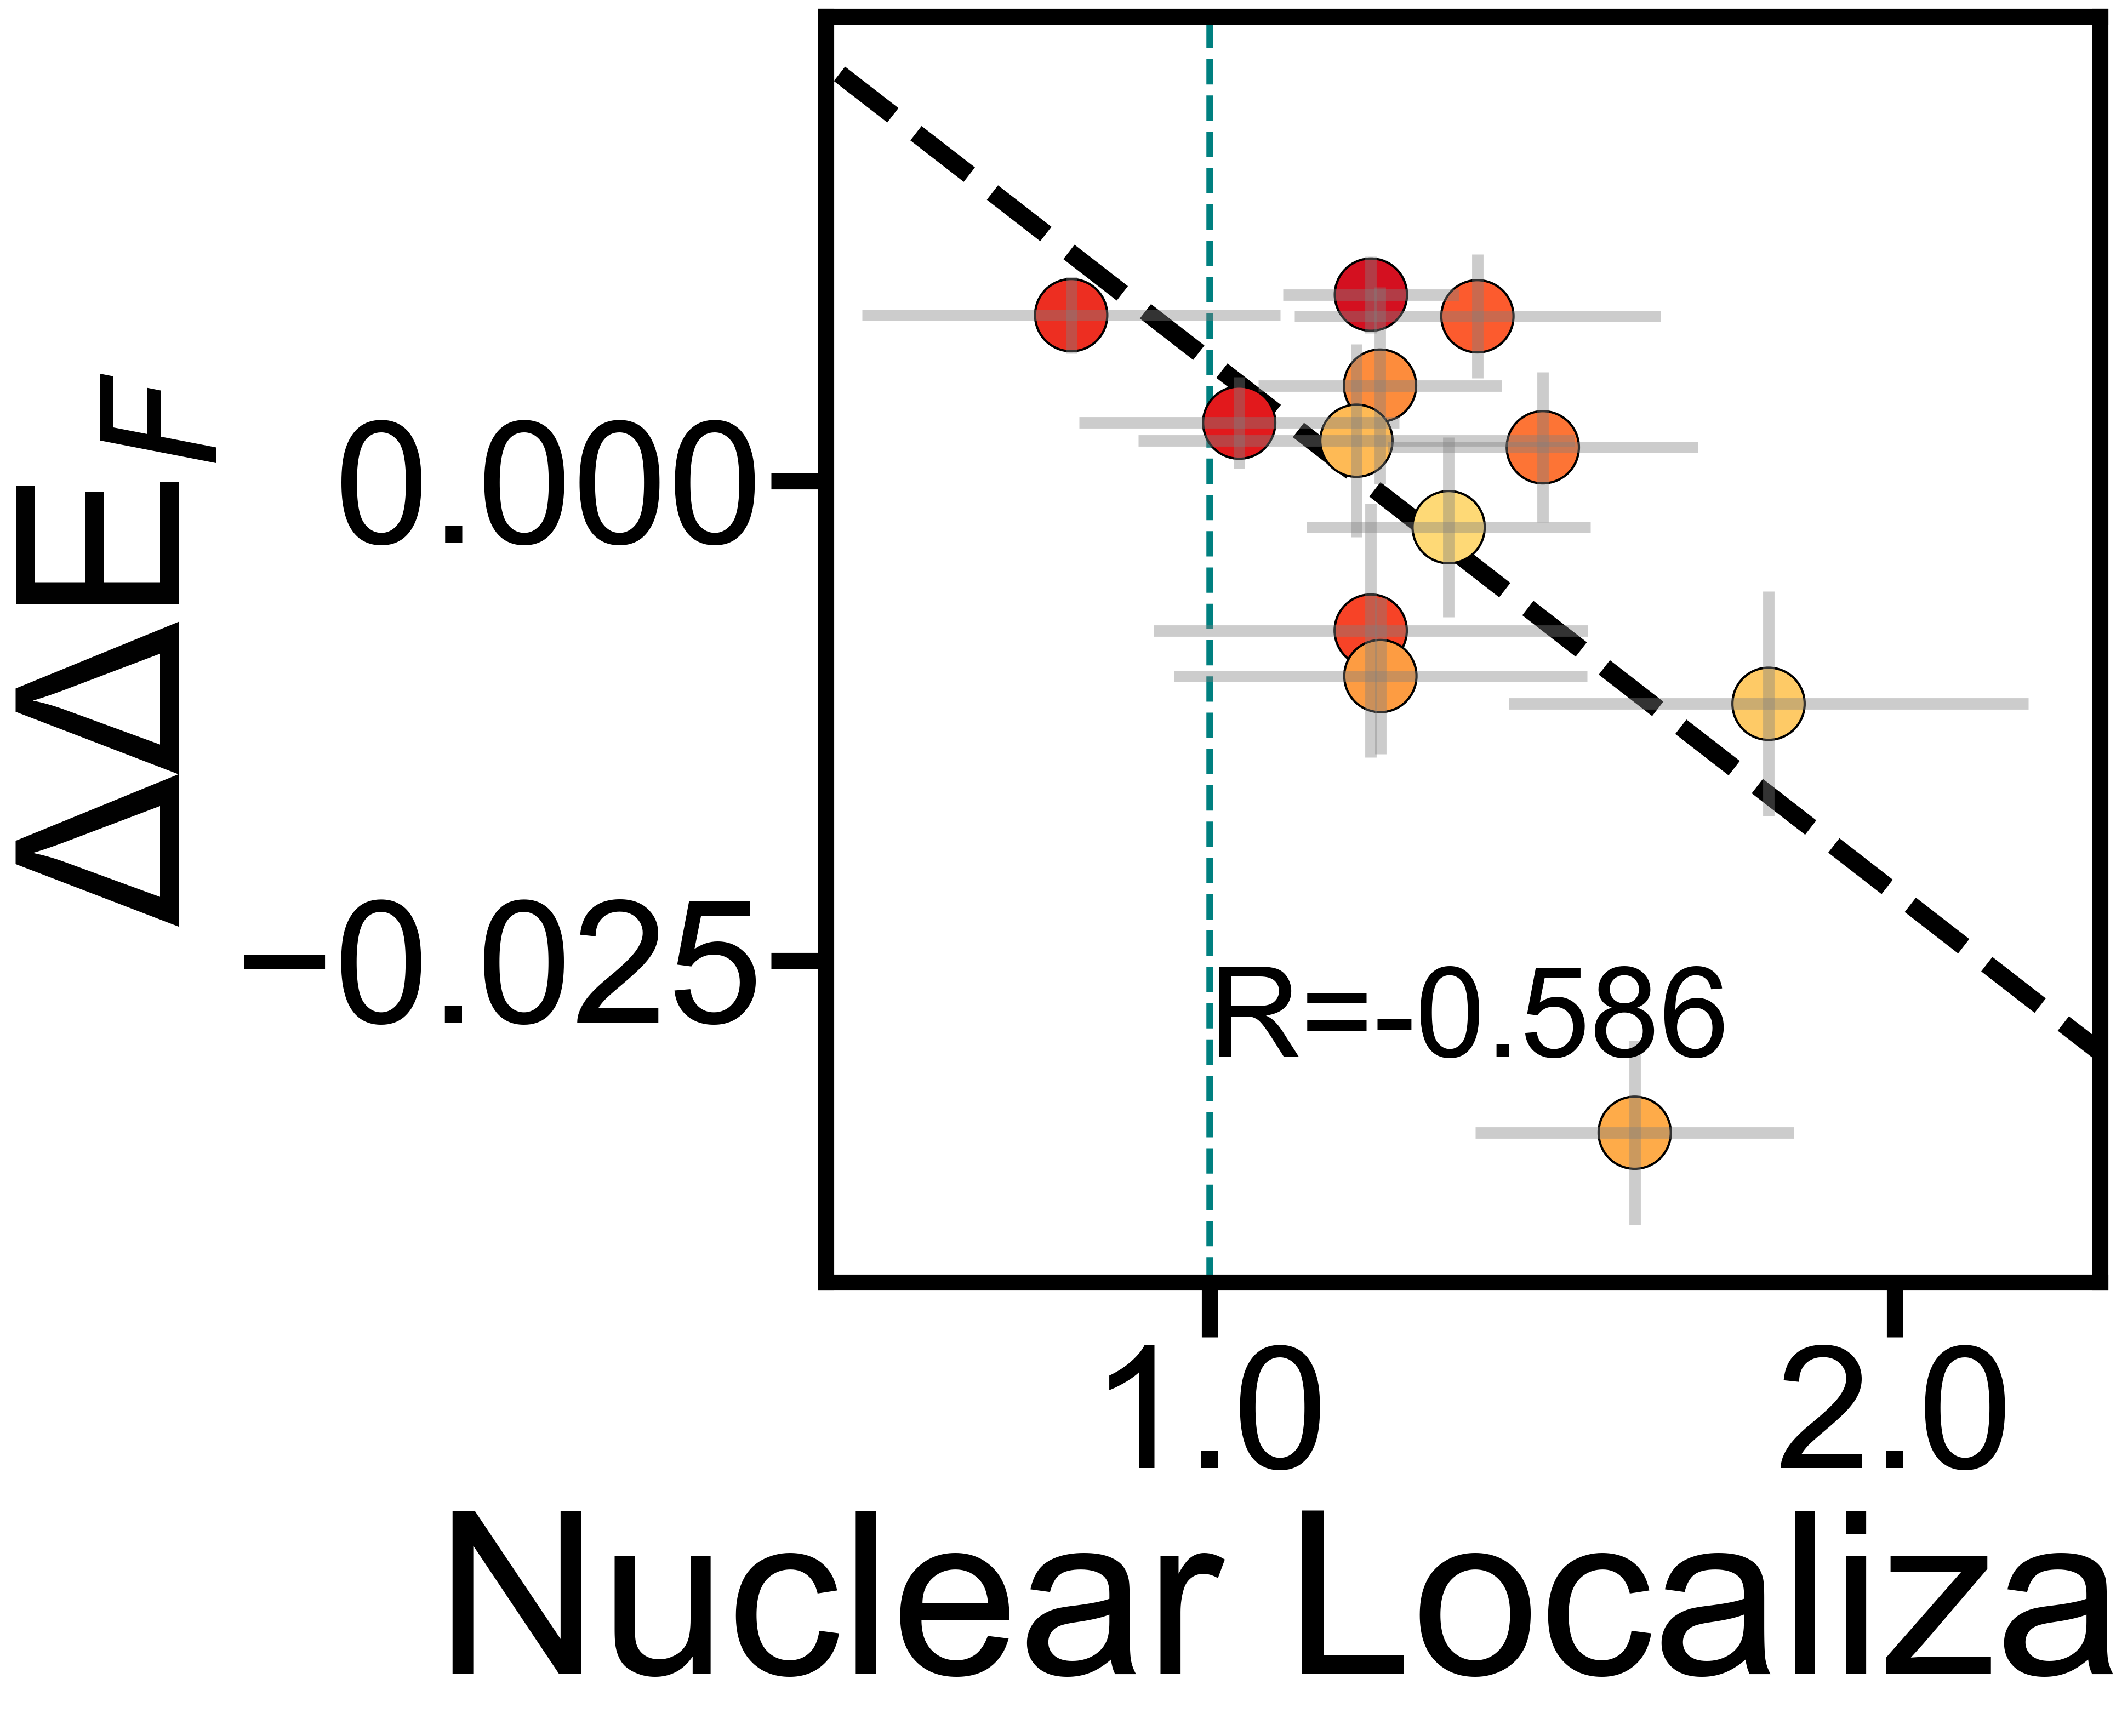

In [355]:
fig, ax = plt.subplots(figsize=(10,10))

delta = "\u0394"

x = new_df['DirectA_ratio']
y = new_df['ddEfret_median'] 

y_std = new_df['dEfret_std']
x_std = new_df['std_ratio']

N=12
colors = plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)).tolist()

res = stats.linregress(x, y)

resort_x = np.array(sorted(x.tolist()))
tmp_x = np.array([0.46, 2.4])
ax.plot(tmp_x, tmp_x*res.slope + res.intercept, c='k', linestyle='--', linewidth=8, zorder=1)

ax.scatter(x, y, s=1000, color=colors, edgecolor='k')
ax.errorbar(x, y, xerr= x_std, yerr=y_std, linewidth=0, elinewidth=5, color='gray', alpha=0.4)
ax.text(1, -0.03, s='R='+str(round(res.rvalue, 3)))
ax.set_ylabel(f"{delta}{delta}E$_F$", fontsize=100)
ax.set_xlabel(f"Nuclear Localization", fontsize=100)

ax.axvline(1.0, linestyle='--', color='teal', linewidth=3, zorder=0)
ax.set_xticklabels([0, 1.0, 2.0])
ylims = ax.get_ylim()
ax.set_xlim([0.44, 2.3])
xlims = ax.get_xlim()
plt.savefig(r'W:\OneDrive\Virus\Paper1\Paper1_figures\ddEfret_directAratio_infection.svg', format='svg', bbox_inches='tight')

In [356]:
dd_df = pd.read_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\figure_3_delta_Efret_noninfect.pkl')

C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\3068687923.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  inter_df = plotting_df.loc[plotting_df['infection']=='noninfected'].groupby('construct', as_index=False)['DirectA_ratio'].agg(['median', 'std'])
C:\Users\Owner\AppData\Local\Temp\ipykernel_30280\3068687923.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([0.0, 1.0, 2.0])


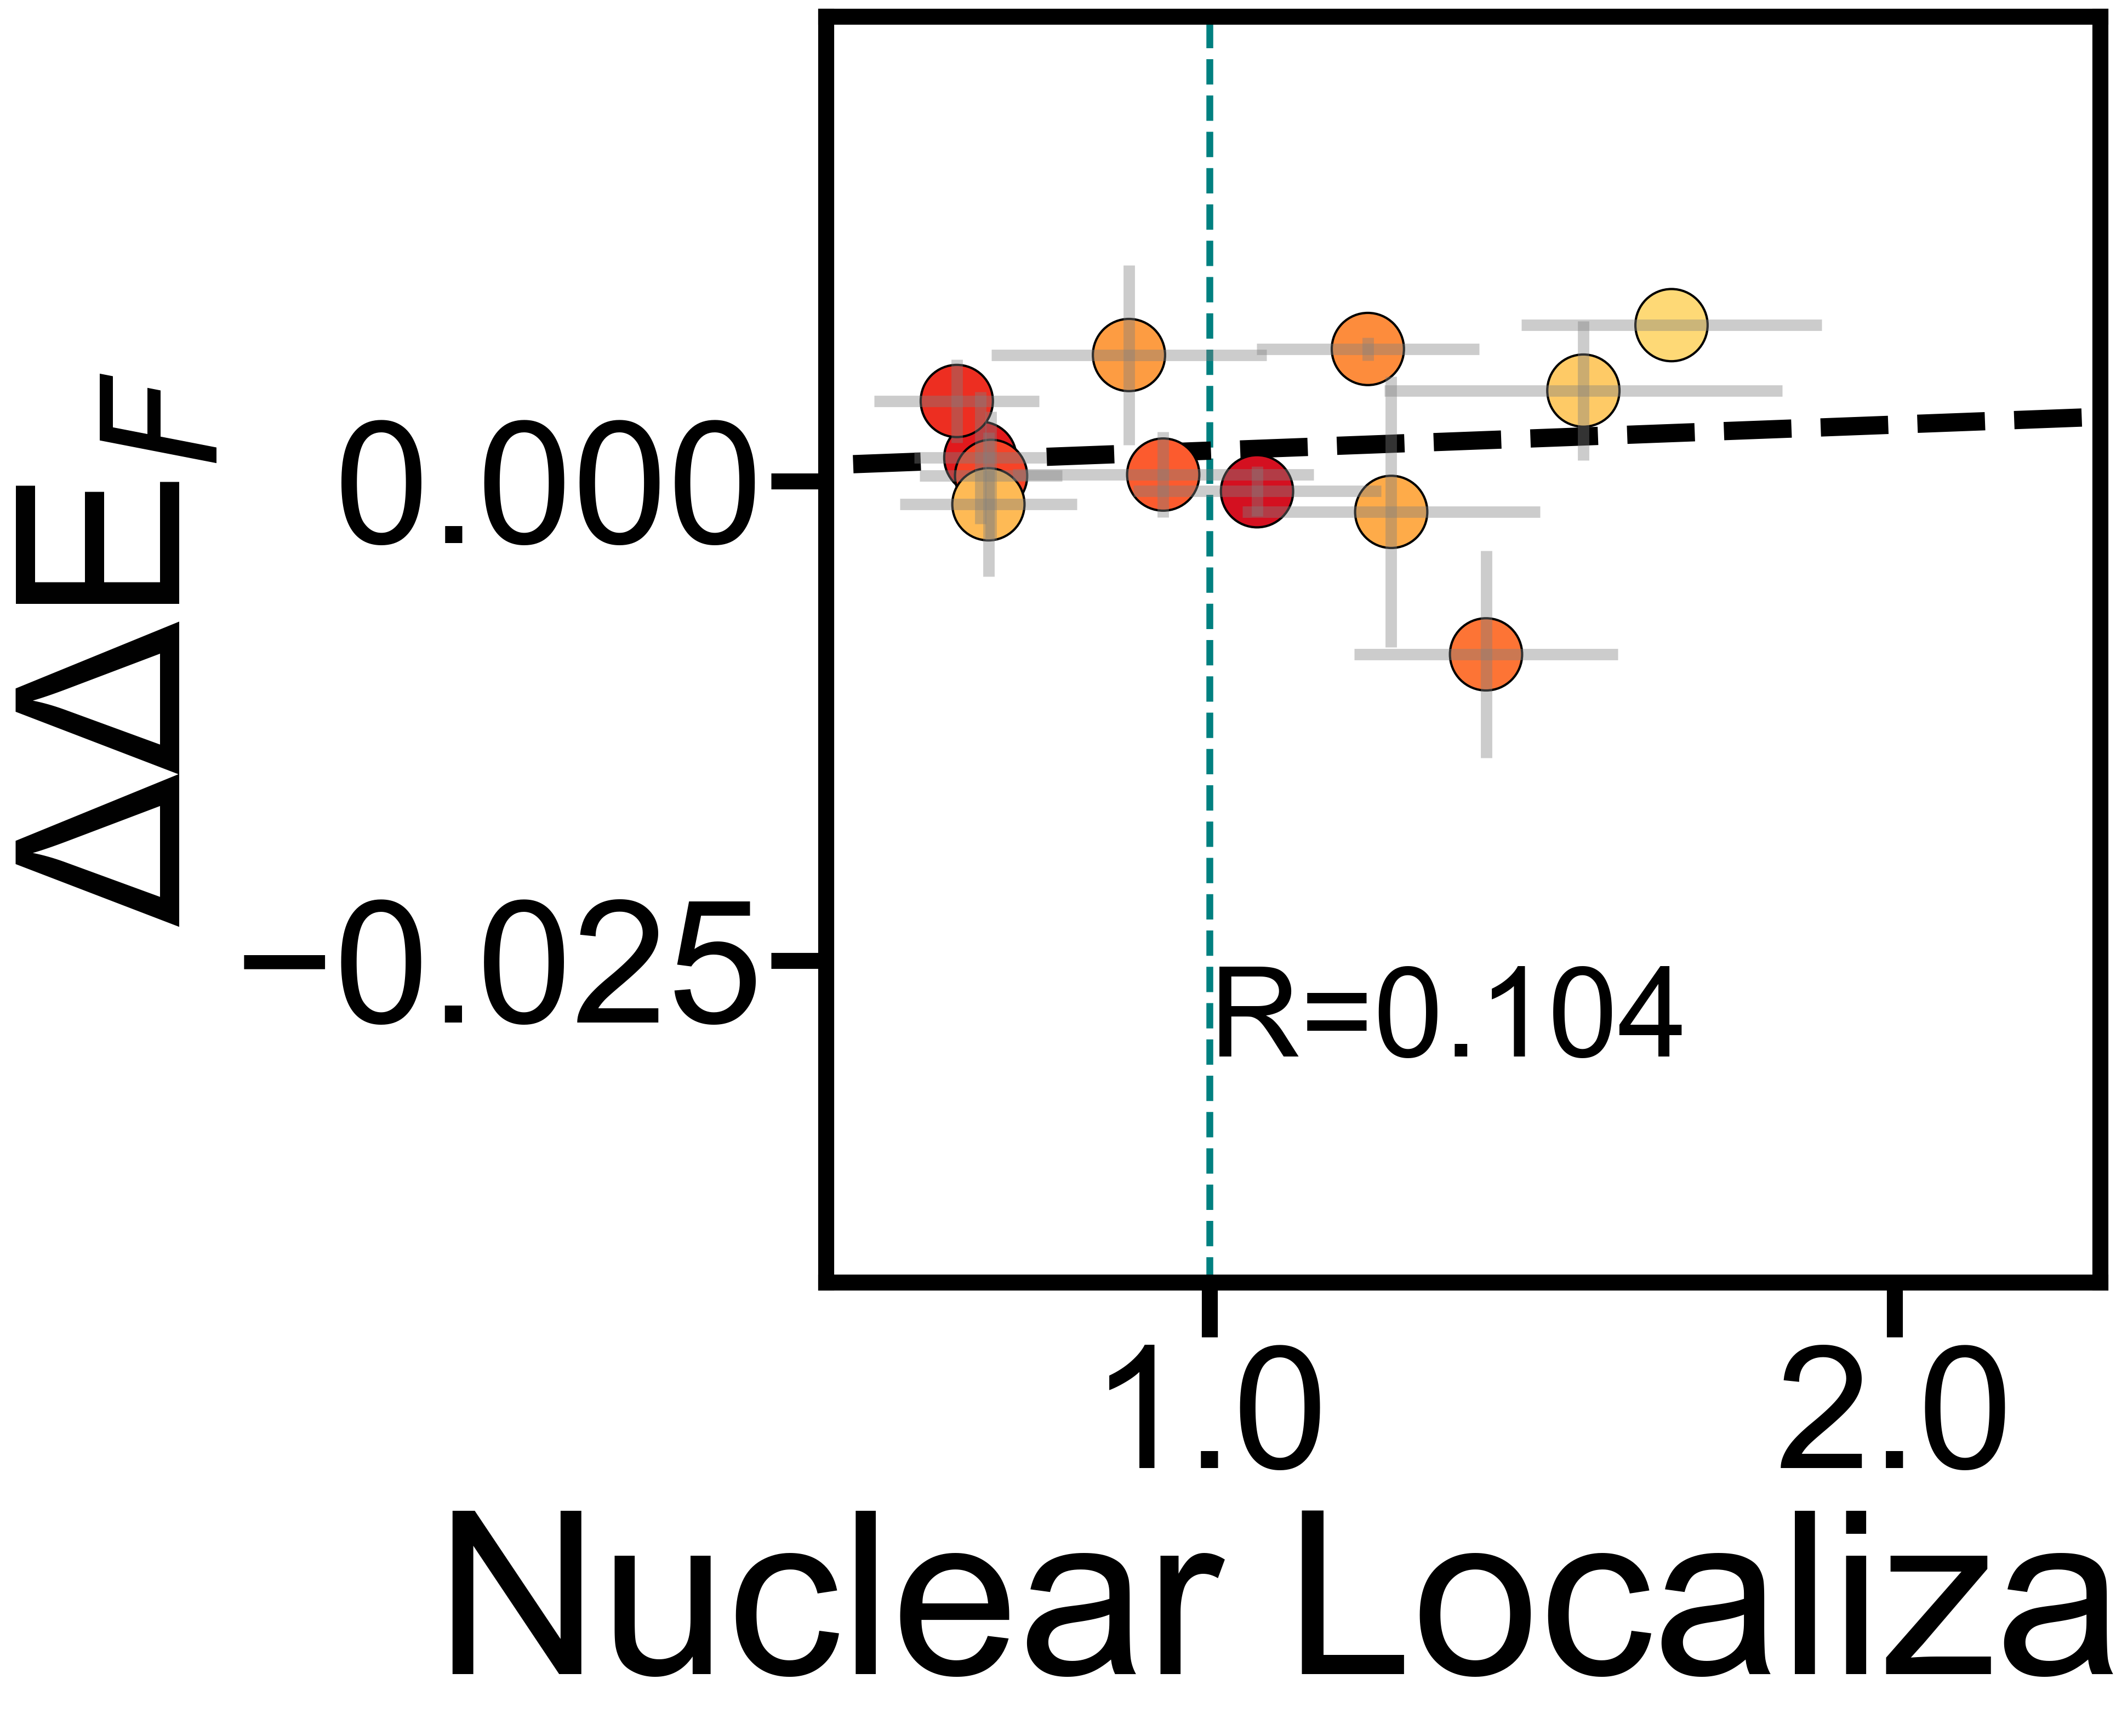

In [357]:
dd_df = pd.read_pickle(r'W:\OneDrive\Virus\Paper1\processed_csvs\figure_3_delta_Efret_noninfect.pkl')

std = dd_df.loc[dd_df['experimentparameter'] == 'noninfected'].groupby('construct', as_index=False)['delta_Efret_median_well'].apply(lambda x: x[2].std())
std = std.rename(columns={'delta_Efret_median_well': 'dEfret_std'})
small_df = dd_df.groupby(['construct'], as_index=False)['experiment_delta_median'].apply(lambda x: x[2] - x[0])
small_df =small_df.rename(columns={'experiment_delta_median': 'ddEfret_median'})
small_df = pd.merge(small_df, std, on ='construct', how='left')

inter_df = plotting_df.loc[plotting_df['infection']=='noninfected'].groupby('construct', as_index=False)['DirectA_ratio'].agg(['median', 'std'])

inter_df = inter_df.rename(columns={'median': 'DirectA_ratio', 'std': 'std_ratio'})
inter_df['construct'] = inter_df['construct'].astype(int)
newx_df = pd.merge(small_df, inter_df, on='construct', how='outer')

fig, ax = plt.subplots(figsize=(10,10))

delta = "\u0394"

x = newx_df['DirectA_ratio']
y = newx_df['ddEfret_median'] 

y_std = newx_df['dEfret_std']
x_std = newx_df['std_ratio']

N=12
colors = plt.cm.YlOrRd(np.linspace(0.8, 0.25, N)).tolist()


res = stats.linregress(x, y)

resort_x = np.array([0.48, 2.4])
ax.plot(resort_x, resort_x*res.slope + res.intercept, c='k', linestyle='--', linewidth=8, zorder=1)

ax.scatter(x, y, s=1000, color=colors, edgecolor='k')
ax.errorbar(x, y, xerr= x_std, yerr=y_std, linewidth=0, elinewidth=5, color='gray', alpha=0.4)

ax.set_xlim(xlims)
ax.axvline(1.0, linestyle='--', color='teal', linewidth=3, zorder=0)
ax.set_xticklabels([0.0, 1.0, 2.0])
ax.text(1, -0.03, s='R='+str(round(res.rvalue, 3)))
ax.set_ylabel(f"{delta}{delta}E$_F$", fontsize=100)
ax.set_xlabel(f"Nuclear Localization", fontsize=100)
ax.set_ylim(ylims)
plt.savefig(r'W:\OneDrive\Virus\Paper1\Paper1_figures\ddEfret_directAratio_noninfect.svg', format='svg', bbox_inches='tight')

In [258]:
dd_df

,construct,experiment,experimentparameter,cell_count,delta_Efret_median_well,delta_Efret_list_well,experiment_delta_median,well_count,cell_population,pvalue,star_value,base_position,subposition_offset,plot_position
0,1,Infection,Growth,"[81, 128, 141, 218, 256, 257, 527, 617, 317]","[0.004333479279617136, -0.004042616923530862, ...","[[-0.004942038502060875, -0.019127185602692776...",-0.003683,9,2542,1.000000,ns,1,-0.217391,0.782609
2,1,Infection,noninfected,"[265, 247]","[-0.005494036431962224, -0.002907035681978365]","[[-0.04105098034812593, -0.035169341654743724,...",-0.004201,2,512,0.842063,ns,1,0.217391,1.217391
0,2,Infection,Growth,"[151, 82, 112, 164, 334, 313, 240, 223, 236]","[0.015697710248584296, 0.00319370292039009, 0....","[[-0.013882019088669317, 0.0015474210388581877...",0.000893,9,1855,1.000000,ns,2,-0.217391,1.782609
2,2,Infection,noninfected,"[112, 156, 28, 119, 98, 150]","[0.008253886745621053, -0.0014954307160688907,...","[[-0.017839938020758894, 0.003281093036189231,...",0.002121,6,663,0.860448,ns,2,0.217391,2.217391
0,3,Infection,Growth,"[192, 207, 252, 254, 248, 256, 297, 299, 343]","[0.003212941341584341, 7.932271759902854e-05, ...","[[-0.017043042739893155, -0.015014380071468492...",-0.001204,9,2348,1.000000,ns,3,-0.217391,2.782609
2,3,Infection,noninfected,"[96, 125, 83, 33, 123, 170, 115]","[0.0042318998586994006, -0.0006578518265824562...","[[-0.02577402656800104, -0.01818557163130813, ...",0.002986,7,745,0.043889,*,3,0.217391,3.217391
0,4,Infection,Growth,"[75, 81, 76, 302, 306, 180, 388, 476, 523]","[0.001920981217132245, 0.011623999450077915, 0...","[[-0.023053775645071217, -0.016855677880885322...",0.001504,9,2407,1.000000,ns,4,-0.217391,3.782609
2,4,Infection,noninfected,"[49, 38, 223, 132, 123]","[0.002450186624550321, 0.0017874717586865152, ...","[[0.015431282188415496, -0.0013314383203678615...",0.001787,5,565,0.308273,ns,4,0.217391,4.217391
0,5,Infection,Growth,"[116, 230, 147, 272, 457, 287, 220, 318, 261, ...","[-0.001300126586098127, 0.007017613692218011, ...","[[-0.005604419278215256, -0.007789623789408451...",-0.002439,10,2903,1.000000,ns,5,-0.217391,4.782609
2,5,Infection,noninfected,"[29, 119, 69, 93, 328, 158, 173]","[0.002585672045883447, -0.0020873487534378565,...","[[0.0012749315496473623, -0.008123303867460463...",-0.002087,7,969,0.984189,ns,5,0.217391,5.217391
